# 01 — Calibración MLE y Simulación Monte Carlo GBM

**Módulo 0 + Módulo 1** del pipeline de valoración de opciones.

Este notebook:
1. Descarga precios históricos del activo subyacente (`DatosSubyacente`)
2. Calibra `μ` y `σ` vía Máxima Verosimilitud con corrección de Itô (`CalibracionMLE`)
3. Simula trayectorias GBM bajo la medida real **P** (`MonteCarloGBM`)
4. Visualiza la distribución de log-retornos y el abanico de trayectorias simuladas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))

import config
from src.resultados_io import cargar_calibracion, cargar_monte_carlo

plt.rcParams["figure.figsize"] = (10, 5)

## Parámetros del activo

In [2]:
calib = cargar_calibracion()

print(f"Ticker              : {config.TICKER}")
print(f"Ventana histórica    : {config.FECHA_INICIO} -> {config.FECHA_FIN}")
print(f"Observaciones        : {len(calib['precios'])} precios diarios")
print(f"Ultimo precio (S0)   : {calib['precios'][-1]:.2f}")

Ticker              : NVDA
Ventana histórica    : 2024-07-03 -> 2026-07-03
Observaciones        : 501 precios diarios
Ultimo precio (S0)   : 194.83


## Serie histórica de precios

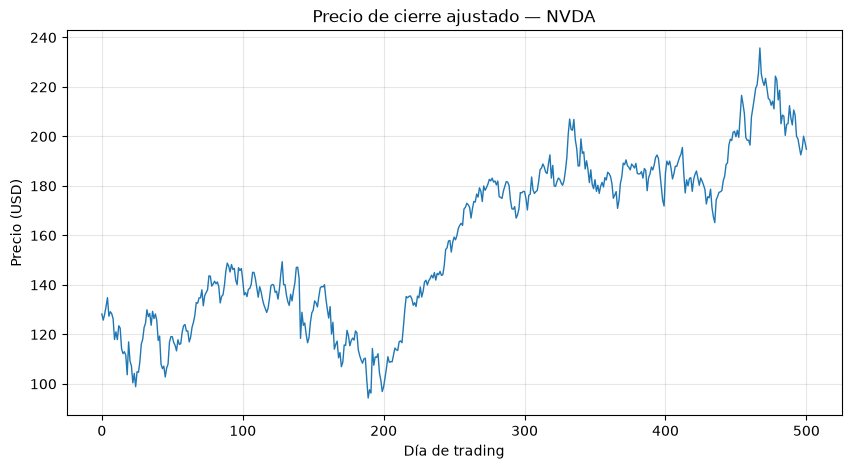

In [3]:
plt.plot(calib["precios"], linewidth=1)
plt.title(f"Precio de cierre ajustado — {config.TICKER}")
plt.xlabel("Día de trading")
plt.ylabel("Precio (USD)")
plt.grid(alpha=0.3)
plt.show()

## Log-retornos

Transformación a la serie estacionaria que asume el modelo GBM:

$$r_i = \ln\left(\frac{S_i}{S_{i-1}}\right)$$

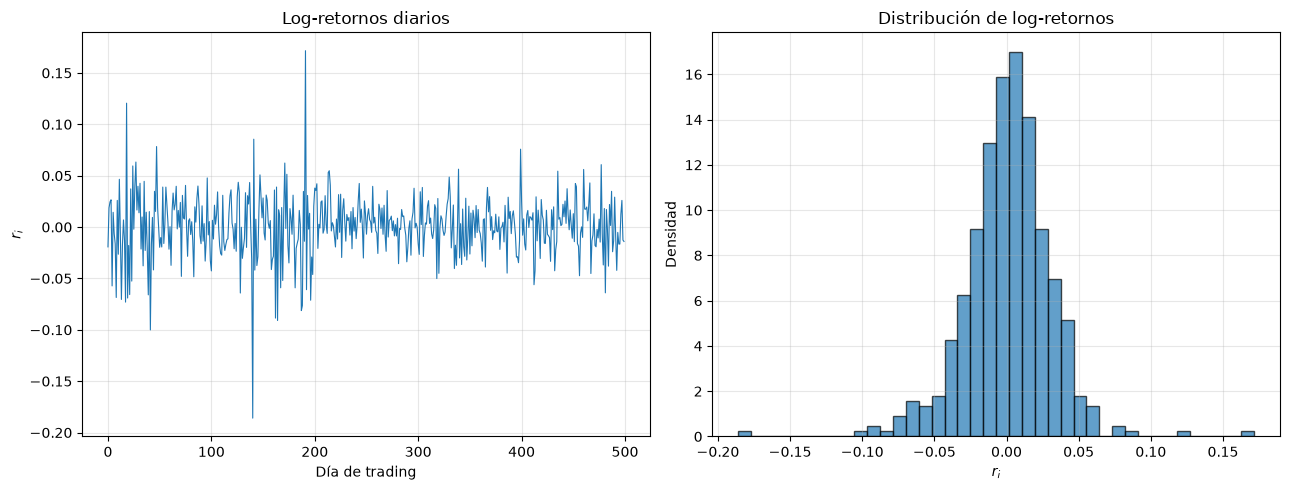

In [4]:
retornos = calib["retornos"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(retornos, linewidth=0.8)
axes[0].set_title("Log-retornos diarios")
axes[0].set_xlabel("Día de trading")
axes[0].set_ylabel("$r_i$")
axes[0].grid(alpha=0.3)

axes[1].hist(retornos, bins=40, density=True, alpha=0.7, edgecolor="black")
axes[1].set_title("Distribución de log-retornos")
axes[1].set_xlabel("$r_i$")
axes[1].set_ylabel("Densidad")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Calibración MLE

$$\hat{\sigma} = \frac{\text{std}(r_i)}{\sqrt{\Delta t}} \qquad
\hat{\mu} = \frac{\bar{r}}{\Delta t} + \frac{\hat{\sigma}^2}{2}$$

El término $+\sigma^2/2$ es la corrección de Itô que recupera el drift real
desde el drift geométrico observado.

In [5]:
mu, sigma = calib["mu"], calib["sigma"]

print(f"{'Parametro':<15} {'Valor':>10}  {'Interpretacion'}")
print("-" * 55)
print(f"{'sigma':<15} {sigma:>9.4f}   Volatilidad anualizada")
print(f"{'mu':<15} {mu:>9.4f}   Drift real anualizado")
print(f"{'sigma^2/2 (Ito)':<15} {sigma**2/2:>9.4f}   Correccion de Ito")

Parametro            Valor  Interpretacion
-------------------------------------------------------
sigma              0.4776   Volatilidad anualizada
mu                 0.3249   Drift real anualizado
sigma^2/2 (Ito)    0.1141   Correccion de Ito


## Simulación Monte Carlo

$$S_{t+\Delta t} = S_t \cdot \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t +
\sigma\sqrt{\Delta t}\, Z\right), \quad Z \sim \mathcal{N}(0,1)$$

Usa `μ` y `σ` calibrados — bajo la medida real **P**, distinta de la medida
neutral al riesgo **Q** que usará Black-Scholes/Crank-Nicolson en el siguiente
notebook (que usa `r`, no `μ`).

In [6]:
# Resultado de la simulación Monte Carlo ya calculada por main.py
# (mismos K, T, tipo de config.py -- no se recalcula aquí)
mc = cargar_monte_carlo()

print(f"S0                 : {mc['S0']:.2f}")
print(f"K (strike)         : {mc['K']:.2f}")
print(f"Tipo de opción     : {mc['tipo'].upper()}")
print(f"E[S_T]             : {mc['S_T'].mean():.2f}")
print(f"std[S_T]           : {mc['S_T'].std():.2f}")
print(f"P(ITM) empírica    : {mc['prob_itm']:.4f}")

S0                 : 194.83
K (strike)         : 195.00
Tipo de opción     : CALL
E[S_T]             : 231.85
std[S_T]           : 83.41
P(ITM) empírica    : 0.6265


## Abanico de trayectorias simuladas

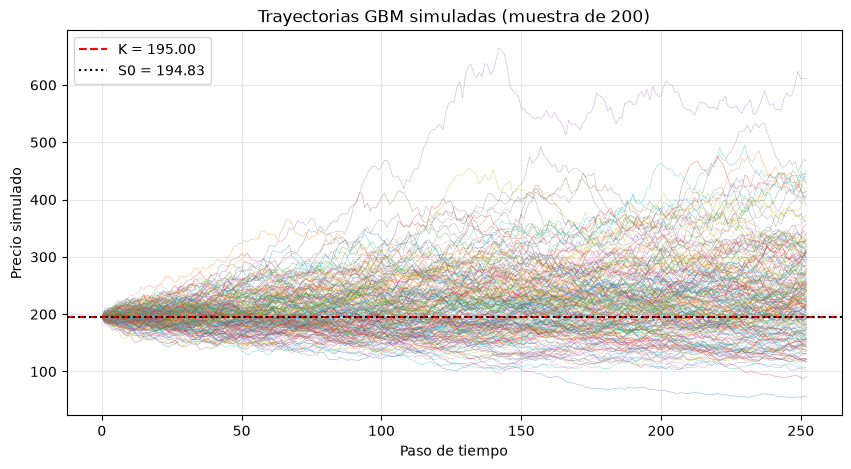

In [7]:
trayectorias_muestra = mc["trayectorias_muestra"]  # muestra de 200, no las 100,000 completas

plt.plot(trayectorias_muestra.T, linewidth=0.4, alpha=0.5)
plt.axhline(mc["K"], color="red", linestyle="--", label=f"K = {mc['K']:.2f}")
plt.axhline(mc["S0"], color="black", linestyle=":", label=f"S0 = {mc['S0']:.2f}")
plt.title(f"Trayectorias GBM simuladas (muestra de {trayectorias_muestra.shape[0]})")
plt.xlabel("Paso de tiempo")
plt.ylabel("Precio simulado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribución de $S_T$ y comparación con $\mathcal{N}(d_2)$

La probabilidad empírica $\hat{P}(S_T > K)$ obtenida aquí se contrastará en
`02_convergencia_crank_nicolson.ipynb` contra $\mathcal{N}(d_2)$ de Black-Scholes.
La diferencia entre ambas es la **prima de riesgo** del mercado.

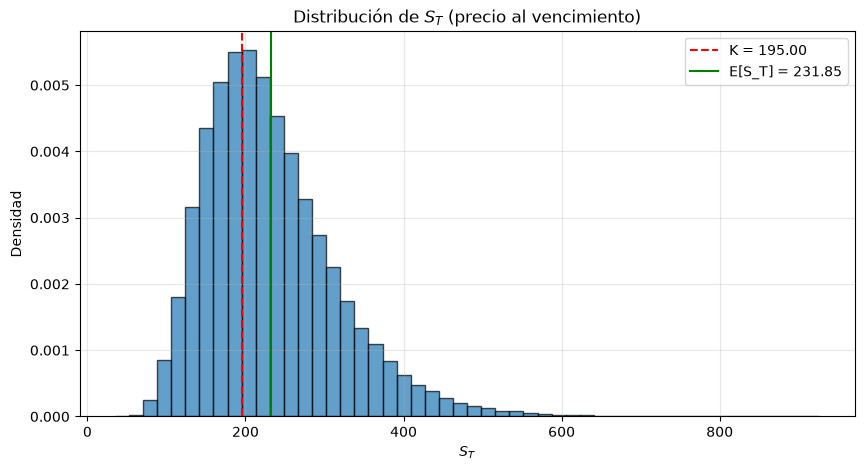

P(S_T > K) empírica (medida P): 0.6265


In [8]:
S_T, K = mc["S_T"], mc["K"]

plt.hist(S_T, bins=50, density=True, alpha=0.7, edgecolor="black")
plt.axvline(K, color="red", linestyle="--", label=f"K = {K:.2f}")
plt.axvline(S_T.mean(), color="green", linestyle="-", label=f"E[S_T] = {S_T.mean():.2f}")
plt.title("Distribución de $S_T$ (precio al vencimiento)")
plt.xlabel("$S_T$")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"P(S_T > K) empírica (medida P): {mc['prob_itm']:.4f}")

## Resumen — valores que viajan al siguiente notebook

| Variable | Valor | Destino |
|---|---|---|
| `S0` | último precio observado | Input de Crank-Nicolson / BS |
| `σ` (sigma) | calibrada por MLE | Parámetro de Black-Scholes / Crank-Nicolson |
| `μ` (mu) | calibrada por MLE | Solo se usa en Monte Carlo, medida real P |
| `P(S_T > K)` empírica | de la simulación | Se compara con $\mathcal{N}(d_2)$ — prima de riesgo |

In [9]:
print(f"S0      = {mc['S0']:.4f}")
print(f"sigma   = {sigma:.4f}")
print(f"mu      = {mu:.4f}")
print(f"P(ITM)  = {mc['prob_itm']:.4f}  (empírica, medida P)")

S0      = 194.8300
sigma   = 0.4776
mu      = 0.3249
P(ITM)  = 0.6265  (empírica, medida P)
